# Threshold calculation for selectivity

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes' ### here the resulting dataframes will be saved
MONKEY_LIST = ['L','N','F'] 
AREAS_MERGED = params_analysis['areas_merged']

AREA = 'V12'

## Data loading

In [4]:
list_df = []
for monkey in MONKEY_LIST:
    for date in DATES[monkey]['RS']:
        path = '/CSNG/studekat/ripple_paper_clean/dataframes/sua_shuffled_phases/monkeyF_all_arrays_date_20240122_B1.pkl'
        with open(path, "rb") as f:
            data = pickle.load(f)
        list_df.append(data)

df_all = pd.concat(list_df)

In [5]:
df_all.head(1)

,bin_edges,bin_edges_angle,phase_counts,env_phase_counts,phase_angles_counts,env_phase_angles_counts,cell_name,channel_order,array,area,train_order,ch_is_noisy_100Hz,ch_is_noisy_120Hz,norm_RB_phase_selectivity_spikes,pref_RB_env_phase_spikes,width_wf_class,area_merged,final_class,wf_direction,rec_date
0,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[-3.141592653589793, -3.078760800517997, -3.01...","[96, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 5, 65, 30, 0, 0, 0, 0, 0, 0...","[0, 3, 1, 0, 0, 1, 1, 0, 2, 2, 1, 0, 0, 4, 2, ...","[24, 16, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",neo.spiketrain.a7ff6ea8a2bb4c4abb7c08827f78ef78,0,1,V1,0,False,False,0.072197,3.129792,wide,V12,DOWN_wide,DOWN,20240122_B1


## Analysis

In [6]:
bin_edges = df_all.iloc[0]['bin_edges']  # bins of the selectivity distrib.
all_phase_counts = np.sum(np.vstack(np.array(df_all['phase_counts'].values)),axis=0)
print(all_phase_counts.shape)

(100,)


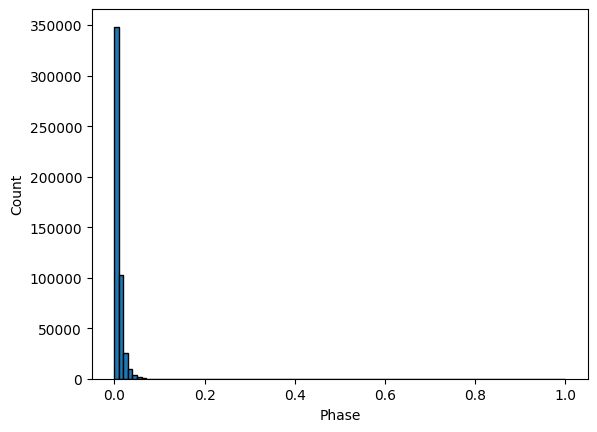

In [7]:
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)

plt.bar(bin_centers, all_phase_counts, width=bin_widths, align='center', edgecolor='k')
plt.xlabel("Phase")
plt.ylabel("Count")
plt.show()


In [8]:
# cumulative distribution
cdf = np.cumsum(all_phase_counts)
cdf = cdf / cdf[-1]   # normalize to 0–1

# find the first bin where CDF exceeds 0.99
idx = np.searchsorted(cdf, 0.99)

# interpolate inside that bin
if idx == 0:
    p99 = bin_edges[0]
else:
    cdf_low = cdf[idx-1]
    cdf_high = cdf[idx]
    bin_low = bin_edges[idx]
    bin_high = bin_edges[idx+1]
    frac = (0.99 - cdf_low) / (cdf_high - cdf_low)
    p99 = bin_low + frac * (bin_high - bin_low)

print(p99)  # This will be used as thresh., rounded to 2 places up
print(idx)

0.04348314606741571
4


In [9]:
print(f'Selectivity threshold is: {np.ceil(p99 * 100) / 100}')

Selectivity threshold is: 0.05
